In [320]:
import numpy as np


class LogisticRegression:
    def __init__(self, lr=0.1, C=1, num_iter=1000):
        self.lr = lr
        self.C = C
        self.num_iter = num_iter
        self.losses = []

    def sigmoid_usual(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid(self, z):
        z = np.array(z, dtype=float)

        positive = z >= 0
        negative = ~positive

        out = np.empty_like(z, dtype=float)

        out[positive] = 1 / (1 + np.exp(-z[positive]))
        out[negative] = np.exp(z[negative]) / (1 + np.exp(z[negative]))

        return out

    def loss(self, probs, y, n):
        eps = 1e-15
        probs = np.clip(probs, eps, 1 - eps)

        loss = -(1 / n) * np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        return loss

    def gradients(self, n, X, y, logits, metrics="neg_log_loss"):
        if metrics == "neg_log_loss":
            return {
                "weights": (1 / n) * np.matmul(X.T, (logits - y))
                + (1 / self.C) * self.weights,
                "bias": (1 / n) * sum(logits - y),
            }

    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias

    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]

        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias
            probs = self.sigmoid(logits)

            grads = self.gradients(n, X, y, probs)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(probs, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    
    def predict(self, X_test):
        probabilities = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        classes = (probabilities >= 0.5).astype(int)
        return classes

    def predict_proba(self, X_test):
        p1 = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        p0 = 1 - p1
        return np.vstack([p0, p1]).T

In [351]:
class Regression:
    def __init__(self, lr=0.001, num_iter=1000):
        self.lr = lr
        self.num_iter = num_iter
        self.weights = np.array([])
        self.bias = 0
        self.losses = []
        
    def __str__(self):
        return self.__class__.__name__
    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias
    
    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]
        
        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias

            grads = self.gradients(n, X, y, logits)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(logits, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    def predict(self, X_test):
        predictions = self.bias + np.dot(X_test, self.weights)
        return predictions


class LinearRegression(Regression):
    def __init__(self, lr=0.001, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
    
    def gradients(self, n, X, y, logits, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (logits - y)),
                "bias": (2 / n) * sum(logits - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2)
        return loss
    

class Lasso(Regression):
    def __init__(self, lr=0.001, alpha=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha

    def gradients(self, n, X, y, logits, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (logits - y)) + self.alpha * np.sign(self.weights),    #l1 weights gradient 
                "bias": (2 / n) * sum(logits - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * np.sum(np.abs(self.weights))   #l1 loss
        return loss
    
    
class Ridge(Regression):
    def __init__(self, lr=0.001, alpha=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha

    def gradients(self, n, X, y, logits, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (logits - y))
                + 2 * self.alpha * self.weights,    #l2 weights gradient 
                "bias": (2 / n) * sum(logits - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * np.sum(self.weights ** 2)   #l2 loss
        return loss


class ElasticNet(Regression):
    def __init__(self, lr=0.001, alpha=1, l1_ratio=0.5, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def gradients(self, n, X, y, logits, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (logits - y)) \
                    + self.alpha * (self.l1_ratio * np.sign(self.weights) +     #l1 weights gradient 
                    2 * self.alpha * self.weights),                             #l2 weights gradient 
                "bias": (2 / n) * sum(logits - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * \
                (self.l1_ratio * np.sum(np.abs(self.weights) +        #l1 loss
                (1 - self.l1_ratio) * np.sum(self.weights ** 2)))     #l2 loss
        return loss

In [322]:
from sklearn.datasets import load_breast_cancer

np.set_printoptions(suppress=True)

early_stopping_value = 0.000001
num_iterations = 100000
C = 1

X, y = load_breast_cancer(return_X_y=True)

In [323]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [324]:
log_reg = LogisticRegression(num_iter=num_iterations, C=C)
log_reg.fit(X_train, y_train)

print(f"Weights: {log_reg.weights}")
print(f"Bias: {log_reg.bias}")
predictions = log_reg.predict(X_test) 
probs = log_reg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Stopped on iteration 249
Weights: [-0.11446293 -0.08318241 -0.11443116 -0.10691415 -0.05319267 -0.07033353
 -0.09235266 -0.1148148  -0.04392204  0.0290711  -0.07905549  0.00481125
 -0.0726569  -0.07111811  0.01249685 -0.01363725 -0.00816733 -0.04744662
  0.01310247  0.02065221 -0.12443906 -0.09592299 -0.12248262 -0.1115675
 -0.07969522 -0.08377584 -0.09693587 -0.12679674 -0.075287   -0.04143166]
Bias: 0.590585058363064
Accuracy: 0.9824561403508771
Logloss: 0.3016799788052125


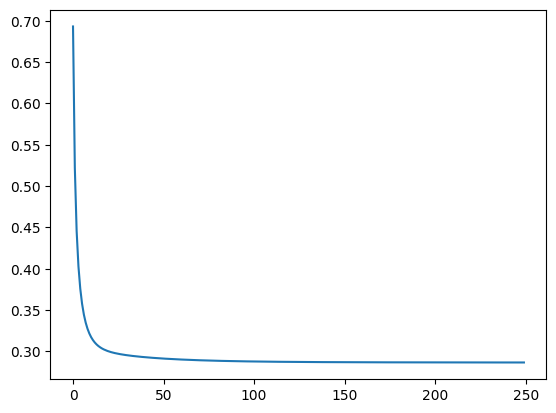

In [325]:
plt.plot(log_reg.losses)

In [326]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)

scaler = StandardScaler()

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_linear = scaler.fit_transform(X_train_linear)
X_test_linear = scaler.transform(X_test_linear)


In [353]:
alpha = 1
learning_rate = 0.01
num_iter = 20000
l1_ratio = 0.5

linreg = LinearRegression(num_iter=num_iter, lr=learning_rate)
lasso = Lasso(num_iter=num_iter, alpha=alpha, lr=learning_rate)
ridge = Ridge(num_iter=num_iter, alpha=alpha, lr=learning_rate)
elasticnet = ElasticNet(num_iter=num_iter, alpha=alpha, l1_ratio=l1_ratio, lr=learning_rate)

models = (linreg, lasso, ridge, elasticnet)
for model in models:
    model.fit(X_train_linear, y_train_linear)

    print(f"Weights of {model}:\n {model.weights}")
    print(f"Bias of {model}:\n {model.bias}")
    predictions = model.predict(X_test_linear) 

    print(f"MSE of {model}: {mean_squared_error(y_test_linear, predictions)}")
    print('-'* 50)

Weights of LinearRegression:
 [  1.36047956 -12.44966182  26.2302024   18.60594781 -42.35932456
  23.55174857   5.34317992  13.83723546  31.22430888   1.99304096]
Bias of LinearRegression:
 153.90291262135852
MSE of LinearRegression: 2821.617438895362
--------------------------------------------------
Stopped on iteration 6611
Weights of Lasso:
 [  1.07395098 -11.28768206  26.91320731  17.86130291 -10.97986367
  -0.00354421  -8.05903312   8.28758133  19.5129164    2.08873602]
Bias of Lasso:
 153.90291262135852
MSE of Lasso: 2805.04806981405
--------------------------------------------------
Stopped on iteration 513
Weights of Ridge:
 [ 2.21340088 -4.57408817 15.55868904 10.72887799 -0.66895855 -1.47191676
 -8.01997201  6.10637809 10.73944767  5.26939104]
Bias of Ridge:
 153.89805723639375
MSE of Ridge: 2993.9033268219573
--------------------------------------------------
Stopped on iteration 505
Weights of ElasticNet:
 [ 2.09420031 -4.39784048 15.4969361  10.63614051 -0.50465172 -1.325

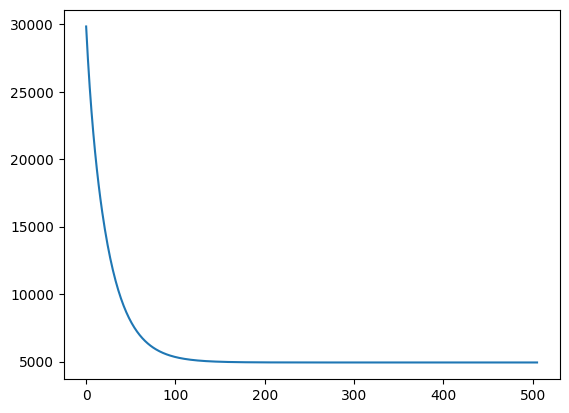

In [355]:
plt.plot(elasticnet.losses)